In [1]:
#to encode numerical features , we use bining and binarization

In [2]:
import numpy as np
import pandas as pd


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


In [4]:
df = pd.read_csv('titanic_train.csv', usecols = ['Age', 'Fare' ,'Survived'])


In [5]:
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
#we will drop rows with null values
df.dropna(inplace = True)

In [7]:
df.shape


(714, 3)

In [8]:
x = df.iloc[:,1:]
y = df.iloc[ : , 0]

In [9]:
#train test split
x_train , x_test , y_train , y_test = train_test_split(df.drop(columns = ['Survived']), df['Survived'] , test_size = 0.2 , random_state = 42)

In [10]:
x_train.head()


,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [11]:
y_train


328    1
73     0
253    0
719    0
666    0
      ..
92     0
134    0
337    1
548    0
130    0
Name: Survived, Length: 571, dtype: int64

In [12]:
clf = DecisionTreeClassifier()

In [13]:
clf.fit(x_train ,y_train)
y_pred = clf.predict(x_test)


In [14]:
accuracy_score(y_test , y_pred)

0.6433566433566433

In [15]:
#using cross val score for more real result
np.mean(cross_val_score(DecisionTreeClassifier() , x , y, cv = 10 , scoring= 'accuracy'))

np.float64(0.6331377151799686)

In [16]:
#Bining
kbin_age = KBinsDiscretizer(n_bins = 10 , strategy = 'kmeans' , encode = 'ordinal')
kbin_fare = KBinsDiscretizer(n_bins = 10 , strategy = 'kmeans' , encode ='ordinal')

In [17]:
#applying all the necessary transformations in the data using column transformer
trf = ColumnTransformer([
    ('first' , kbin_age ,[0]),
    ('second' , kbin_fare , [1])
])

In [18]:
x_train_transformed = trf.fit_transform(x_train) #transformation applied to x_train
x_test_transformed = trf.transform(x_test) #transformations applied to x_test

In [19]:
trf.named_transformers_


{'first': KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='kmeans'),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='kmeans')}

In [20]:
trf.named_transformers_['first'].bin_edges_[0]




array([ 0.42      ,  8.95396298, 17.85460643, 24.83453636, 32.41986162,
       40.34522257, 48.11193503, 56.08004386, 64.26754386, 72.58333333,
       80.        ])

In [21]:
trf.named_transformers_['second'].bin_edges_


array([array([  0.        ,  18.31084718,  38.12143114,  62.67965675,
               84.02620056, 107.12413381, 138.32481   , 185.67419167,
              237.86718333, 385.651575  , 512.3292    ])             ],
      dtype=object)

In [22]:
trf.named_transformers_['first'].n_bins_


array([10])

In [23]:
output= pd.DataFrame({
    'age' : x_train['Age'],
    'age_transformed' : x_train_transformed[: , 0],
    'fare' : x_train['Fare'],
    'fare_transformed' : x_train_transformed[:,1]
})

In [24]:
trf.named_transformers_['first'].bin_edges_[0].tolist()


[0.42,
 8.953962984723852,
 17.85460643124876,
 24.834536361178692,
 32.419861619861614,
 40.34522257403613,
 48.11193502824858,
 56.080043859649116,
 64.26754385964912,
 72.58333333333333,
 80.0]

In [25]:
trf.named_transformers_['second'].bin_edges_[0].tolist()

[0.0,
 18.3108471759676,
 38.12143113636364,
 62.67965675438596,
 84.02620056390977,
 107.12413380952381,
 138.32481,
 185.67419166666667,
 237.86718333333332,
 385.651575,
 512.3292]

In [27]:
output['age_labels'] = pd.cut(x = x_train['Age'] , bins = trf.named_transformers_['first'].bin_edges_[0].tolist())

output['Fare_labels'] = pd.cut(x = x_train['Fare'], bins = trf.named_transformers_['second'].bin_edges_[0].tolist())

In [28]:
output.sample(5)


,age,age_transformed,fare,fare_transformed,age_labels,Fare_labels
634,9.0,1.0,27.9000,1.0,"(8.954, 17.855]","(18.311, 38.121]"
423,28.0,3.0,14.4000,0.0,"(24.835, 32.42]","(0.0, 18.311]"
178,30.0,3.0,13.0000,0.0,"(24.835, 32.42]","(0.0, 18.311]"
183,1.0,0.0,39.0000,2.0,"(0.42, 8.954]","(38.121, 62.68]"
786,18.0,2.0,7.4958,0.0,"(17.855, 24.835]","(0.0, 18.311]"


In [39]:
#creating fnc

def discretize(bins, strategy ) :
    kbin_age = KBinsDiscretizer(n_bins = bins , encode = 'ordinal', strategy = strategy)
    kbin_fare = KBinsDiscretizer(n_bins = bins , encode = 'ordinal', strategy = strategy)

    trf = ColumnTransformer([
        ('first', kbin_age , [0]),
        ('second', kbin_fare, [1])
    ])

    x_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), x, y , cv= 10 , scoring= 'accuracy')))

    plt.figure(figsize = (14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(x_trf[:,0], color = 'red')
    plt.title('After')


    plt.figure(figsize = (14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(x_trf[:,1], color = 'red')
    plt.title('After')




    plt.show()

0.6359154929577464


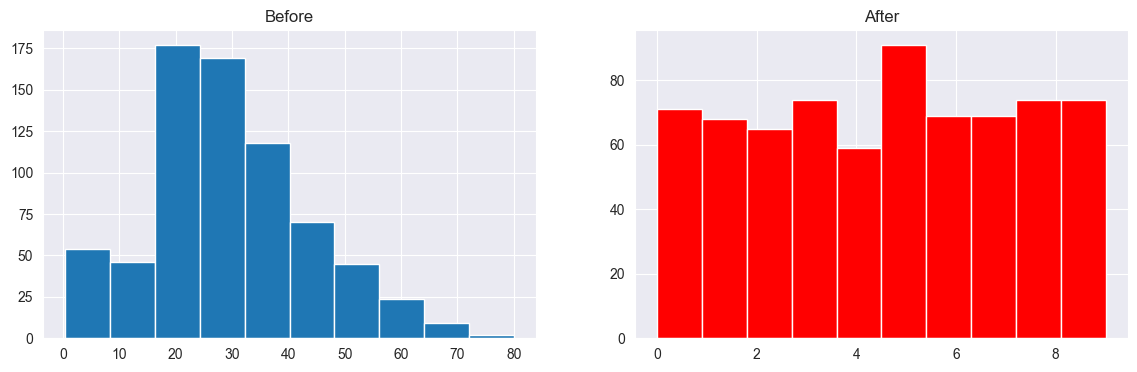

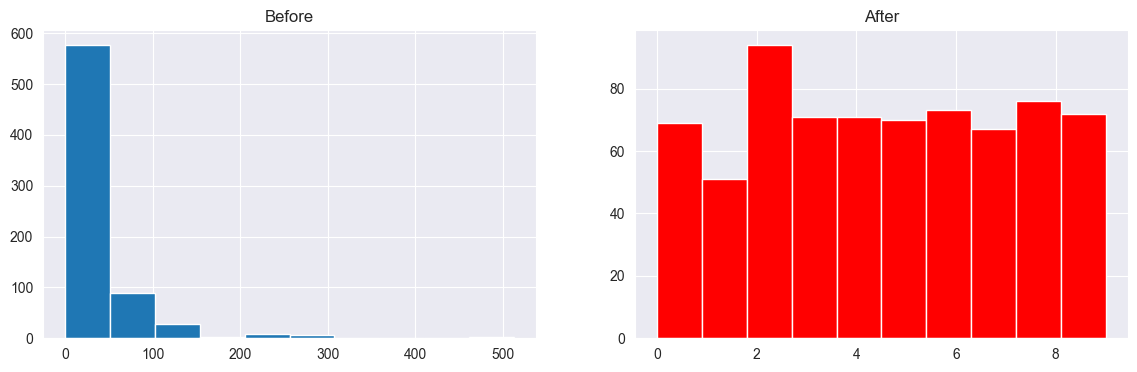

In [40]:
discretize(10 ,'quantile')